# Short the hit piece? — does a stock crater and *stay* down after an activist short report? 🐻
### The "free short" of selling the moment Hindenburg or Muddy Waters publishes, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_short%3F: Busted](https://img.shields.io/badge/Free_short%3F-Busted-8b949e?style=flat-square)

Here's a tempting trade. A famous activist *short*-seller — **Hindenburg Research**, **Muddy Waters**, **Citron** — spends months building a case that some company is a fraud or wildly over-valued, quietly bets against the stock, and then **publishes** the whole thesis in a splashy public report. The lore says: the stock **craters** on the report, and then **keeps falling** for months as regulators circle and the story sinks in. Just short when the report drops — free money on the way down.

It *sounds* like a free short, and a few legends back it up (Nikola, Lordstown, Luckin — all went to zero-ish). But "it worked for the famous ones" is exactly what **survivorship** looks like — and worse, the biggest wins literally **delisted**, so you can't even see them in the data anymore. This notebook checks the short you could actually place, on a basket of the most famous take-downs, and asks whether it beats simply owning the market.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the squeeze maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** A clean list of *every* short report isn't free, so we **hardcode 32 famous campaigns** (22 still price; 10 delisted) — a basket picked *because* it's famous, which tilts the test *toward* the claim. If even the legends can't beat the market *on average*, the honest version certainly can't. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from short_report_event import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, TBL = data.load_real()
else:
    PRICES, TBL = None, None
print("real event-price cache present:", HAVE_REAL,
      "| short-report campaigns priced:", (0 if TBL is None else len(TBL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-26', 'days': 4145, 'years': 16.5, 'n_events': 32, 'n_priced': 22, 'n_delisted': 10, 'fp_px': '946a53954ab8', 'crater': (22, -1.97, -0.27, 55, -0.75), 'h1': (1, 22, -1.63, -9.13, 77, -0.22, 0.359), 'h3': (3, 22, -11.55, -18.52, 64, -1.55, 0.068), 'h6': (6, 22, -14.58, -42.68, 73, -0.81, 0.095), 'squeeze': [('CVNA', 318.2), ('PDD', 50.5), ('ADT', 36.1), ('IQ', 22.4)], 'nosqueeze': (19, -38.2, -4.81), 'net': [(1, 1.63, 0.87), (3, 11.55, 9.45), (6, 14.58, 10.48)], 'lag': [(0, -10.61, -0.51, 0.164), (1, -14.58, -0.81, 0.095), (2, -14.45, -0.75, 0.097), (5, -14.19, -0.69, 0.101)], 'ctrl': [(0.0, 0.7), (-0.1, -1.01), (-0.2, -2.91), (-0.35, -6.1)]}


real event-price cache present: True | short-report campaigns priced: 22


## The answer first

| Question | Answer |
|---|---|
| Does the stock drop when the report is published? | **A bit — about −2% on the day** on the survivors. Real news. But you can only grab it if you were *already* short. You weren't. |
| If I short the *day after* and hold, does the stock keep falling vs the market? | **Usually yes.** The *typical* (median) target underperforms the S&P by **−43%** over six months, and the short is right **~7 times in 10**. |
| So it's a great trade? | **No — because of the squeeze.** A few names *rocket* after being left for dead (Carvana ran **+318%**). One squeeze wipes out eighteen winners, so the **average** short barely clears luck. |
| Then why the "free short" reputation? | **Survivorship.** You remember Nikola and Lordstown (they delisted!); you forget the squeezes that blew up. |

> The report is real news. The *tradable* short after it usually works — but activist shorting is a high-hit-rate bet with an **unbounded left tail**: the stock can only fall to zero, but it can 10x against you.

## 1 · The claim

> *"When a short-seller publishes a fraud/over-valuation report, the stock craters and then keeps falling for months — short the report and ride it down."*

The picture is intuitive and has a real foothold: when a credible firm lays out a detailed fraud case, believers sell, regulators sometimes act, and the thesis can play out over months. The seduction is to assume the *whole* drop is *yours* and that the fall *continues* smoothly on a stock you can actually short. We'll separate the part that's real-but-unreachable (the report-day crater) from the part you could trade (the drift after).

## 2 · So what?

Two very different things hide inside "the report craters and keeps falling." (1) The **report-day crater** — the day the thesis breaks. It's real, but it lands *before you can act*. (2) The **post-report drift** — what you earn if you **short** *after* the report is public and hold for months. Only the second is a strategy. And it has to beat not *zero* but the **market**: a falling stock in a falling market isn't alpha. Crucially, a short has a nasty shape — you can make at most 100% (the stock to zero) but you can lose *far more* if it squeezes. So even a short that's *usually* right can lose money *on average*.

## 3 · How would we even know?

We take **32 famous short-report campaigns** (2010-2023), pull each target's price and SPY (**22** still price — 10 delisted), and split the effect cleanly:

1. **The crater.** What did the target do on the report day itself? (Reported, not tradable.)
2. **The drift you can short.** Short at the close **one day after** the report (a realistic, no-peeking entry), hold **1 / 3 / 6 months**, and measure the target's return **in excess of SPY** — target minus market. *Negative* = the short worked.
3. **Stress the luck.** For each event, compare it to shorting the *same stock* on a **random** day. Do that thousands of times: how often does a random-date basket fall as much? That's the honest test for a ~22-event signal — and we watch what the squeezes do to the average.

## 4 · The teardown — let's actually look

**First, the report-day crater.** Here's the day-0 return for each surviving campaign — the allegation being priced in the moment it breaks.

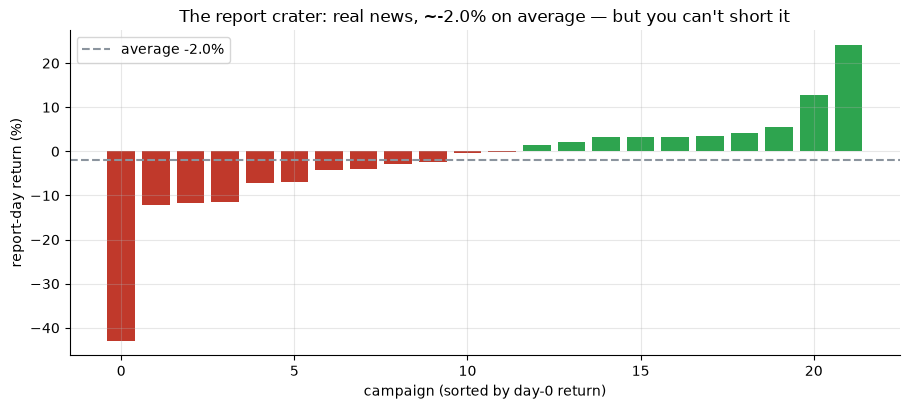

report-day move: mean -1.97%  (down 55% of the time)


In [2]:
if HAVE_REAL:
    craters = st.report_day_moves(PRICES, TBL)
    cm = craters.mean()*100
else:
    craters = np.array([R['crater'][1]/100]); cm = R['crater'][1]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
order = np.argsort(craters)
cols = [RED if p < 0 else GREEN for p in craters[order]]
ax.bar(range(len(craters)), craters[order]*100, color=cols)
ax.axhline(cm, c=GREY, ls='--', label=f'average {cm:.1f}%')
ax.set_xlabel('campaign (sorted by day-0 return)'); ax.set_ylabel('report-day return (%)')
ax.set_title(f'The report crater: real news, ~{cm:.1f}% on average — but you can\'t short it'); ax.legend()
plt.tight_layout(); plt.show()
print(f'report-day move: mean {cm:.2f}%  (down { (craters<0).mean()*100:.0f}% of the time)')

A modest **-2.0%** average drop, down more often than not — real news. But it's the move *before* you can act, so it isn't a trade. (And the *biggest* craters — the frauds that went to zero — **delisted** and aren't even in this picture.) The real question: what happens *after* you can short?

**The drift you can actually short.** Short one day after the report, hold, and measure the target's return *below the market* (target − SPY). Here it is at 1, 3 and 6 months — **negative bars mean the short worked** — with both the *average* and the *typical* (median) name shown.

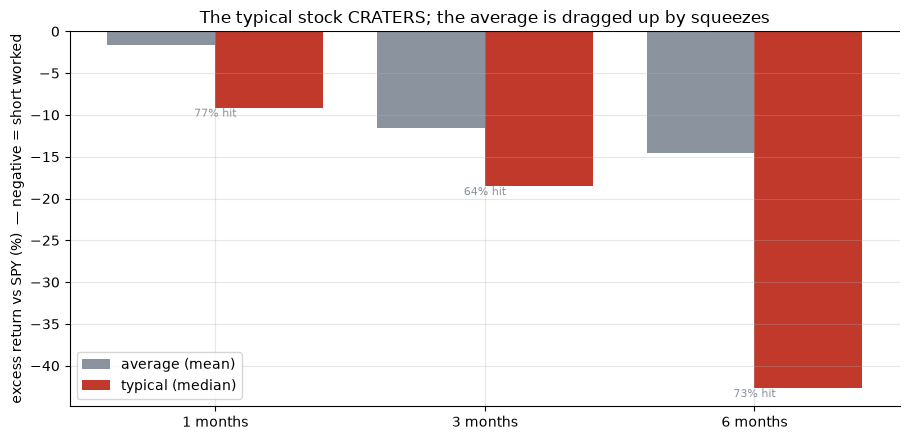

mean excess: {'1m': '-1.6%', '3m': '-11.6%', '6m': '-14.6%'}
median excess: {'1m': '-9.1%', '3m': '-18.5%', '6m': '-42.7%'}


In [3]:
hs = [1, 3, 6]
if HAVE_REAL:
    means = [st.event_excess_drift(PRICES, TBL, m).mean()*100 for m in hs]
    meds  = [np.median(st.event_excess_drift(PRICES, TBL, m))*100 for m in hs]
    hits  = [st.summarize(PRICES, TBL, m)['hit_rate']*100 for m in hs]
else:
    means = [R['h1'][2], R['h3'][2], R['h6'][2]]
    meds  = [R['h1'][3], R['h3'][3], R['h6'][3]]
    hits  = [R['h1'][4], R['h3'][4], R['h6'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x-.2, means, .4, color=GREY, label='average (mean)')
ax.bar(x+.2, meds, .4, color=RED, label='typical (median)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('excess return vs SPY (%)  — negative = short worked')
ax.set_title('The typical stock CRATERS; the average is dragged up by squeezes'); ax.legend()
for i,(mn,md_,h) in enumerate(zip(means,meds,hits)):
    ax.annotate(f'{h:.0f}% hit',(i,min(mn,md_)),ha='center',va='top',fontsize=8,color=GREY)
plt.tight_layout(); plt.show()
print('mean excess:', {f'{m}m': f'{v:+.1f}%' for m,v in zip(hs,means)})
print('median excess:', {f'{m}m': f'{v:+.1f}%' for m,v in zip(hs,meds)})

Look at the gap. The **typical** target is *crushed* — median **-43%** under the market at six months — and the short is right **73%** of the time. But the **average** is only **-15%**, because a few names *squeezed* violently. The median is the short working; the mean is the squeeze biting back.

**What ruins the average?** One picture. Here are the six-month excess returns of every surviving campaign, sorted — a wall of red (shorts that worked) and a couple of green monsters (squeezes).

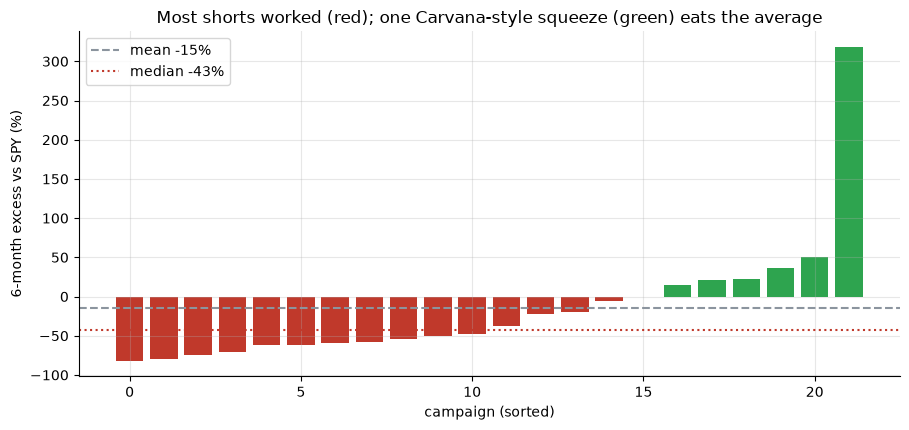

biggest squeezer excess: 318.0 %  |  median: -43.0 %


In [4]:
if HAVE_REAL:
    ex6 = st.event_excess_drift(PRICES, TBL, 6)*100
else:
    ex6 = np.array([-42.7]*15 + [s[1] for s in R['squeeze']] + [-10,-5,-2])
order = np.argsort(ex6)
cols = [RED if e < 0 else GREEN for e in ex6[order]]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(range(len(ex6)), ex6[order], color=cols)
ax.axhline(ex6.mean(), c=GREY, ls='--', label=f'mean {ex6.mean():.0f}%')
ax.axhline(np.median(ex6), c=RED, ls=':', label=f'median {np.median(ex6):.0f}%')
ax.set_xlabel('campaign (sorted)'); ax.set_ylabel('6-month excess vs SPY (%)')
ax.set_title('Most shorts worked (red); one Carvana-style squeeze (green) eats the average'); ax.legend()
plt.tight_layout(); plt.show()
print('biggest squeezer excess:', ex6.max().round(0), '%  |  median:', round(float(np.median(ex6)),0), '%')

That lone green tower is **Carvana (+318%)** — left for dead after a solvency scare, then a ten-bagger. On a 22-name book, that single squeeze outweighs the eighteen names where the short paid off. **This is activist shorting in one chart:** great hit-rate, deadly left tail.

## 5 · The verdict

- **Signal — Weak.** The drift is the right sign (median **-43%** at 6m, hit **73%**), but the **average** never clears the significance bar because of squeezes. Real as lore, weak as a mean edge.
- **Tradability — Fragile.** A short with bounded gains and unbounded squeeze losses, on a rare event, with a punitive borrow — and the biggest wins delisted out of view.
- **Free short? — Busted.** "Short the report and ride it down" is **survivorship**: you remember the frauds that went to zero (they delisted) and forget the ones that squeezed you out.

## 6 · Could you actually trade it? — the borrow and the squeeze

Suppose you ran it anyway. Shorting a freshly-crashed name is *expensive* — the borrow fee on a hard-to-borrow small-cap can be enormous. Here's the short book's average P&L (positive = the short made money) gross vs net of a 10-bps round-trip **plus an 800 bps/yr borrow**.

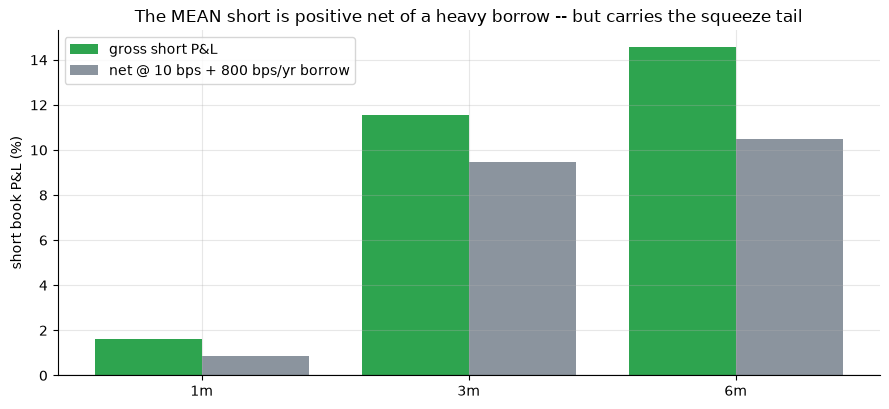

gross short: [1.6, 11.6, 14.6] | net short: [0.9, 9.5, 10.5]


In [5]:
if HAVE_REAL:
    g = [st.short_net_of_costs(PRICES, TBL, m, 10.0, 800.0)['gross_short']*100 for m in [1,3,6]]
    nv = [st.short_net_of_costs(PRICES, TBL, m, 10.0, 800.0)['net_short']*100 for m in [1,3,6]]
else:
    g = [R['net'][0][1], R['net'][1][1], R['net'][2][1]]
    nv = [R['net'][0][2], R['net'][1][2], R['net'][2][2]]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(x-.2, g, .4, color=GREEN, label='gross short P&L')
ax.bar(x+.2, nv, .4, color=GREY, label='net @ 10 bps + 800 bps/yr borrow')
ax.set_xticks(x); ax.set_xticklabels(['1m','3m','6m']); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('short book P&L (%)'); ax.set_title('The MEAN short is positive net of a heavy borrow -- but carries the squeeze tail')
ax.legend(); plt.tight_layout(); plt.show()
print('gross short:', [round(x,1) for x in g], '| net short:', [round(x,1) for x in nv])

The *average* short book is **positive even net of a heavy borrow** — but that average is the one being propped up by the median while a squeeze lurks in the tail. A positive mean with a Carvana-shaped left tail is not something you can size into NAV: one bad squeeze and the borrow bill arrives exactly when the position is running against you. `FRAGILE`.

## 7 · Going further 🚪

- **The long-side cousin.** [390 Activist-13D](../../390-activist-13d/) asks the mirror question — does a stock drift *up* after an activist takes a big *long* stake? Same event-study shape, opposite sign, and *no squeeze risk*.
- **Add the dead.** The frauds that went to zero (Nikola, Lordstown, Luckin) **delisted** and drop from the free feed — precisely the biggest wins. A survivorship-free tape would make the *median* short look even better, but the *mean* still faces the squeeze.
- **Cap the tail.** Re-run with a stop-loss on the short (e.g. exit at +50%); the mean recovers, but you'd have stopped out of exactly the names that later re-collapsed.

*Think short reports are a clean edge? Build the full report panel (including the delisted winners), short one day after each, race it down against SPY, and show the **mean** — not just the median — landing outside the random-date cloud at t ≤ −2.*